# Zadaca 2

IMplementirati BILO KAKAV faktorizacijski model za recommendation NA BILO kojem setu.

Mora se vidjeti skup podataka, mora se videjti SPARSE (suplja) matrica

I kakva je matrica poslije

Unos biblioteka

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

Ucitavanje Amazon Electronics dataseta

In [3]:
df = pd.read_csv('ratings_Electronics.csv',
names=['userId', 'productId', 'rating', 'timestamp'])

print(" Dimenzije \n")
print(f" Redovi: {len(df):,}")
print(f" Kolone: {df.shape[1]}")

print("\n Tipovi podataka \n")
print(df.dtypes)

print("\n Prvih 5 redova ")
df.head()

 Dimenzije 

 Redovi: 7,824,482
 Kolone: 4

 Tipovi podataka 

userId           str
productId        str
rating       float64
timestamp      int64
dtype: object

 Prvih 5 redova 


,userId,productId,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


EDA - Eksploratorna analiza podataka

In [4]:
print(" SAŽETAK SKUPA PODATAKA ")
print(f" Ukupno ocjena : {len(df):,}")
print(f" Broj korisnika : {df['userId'].nunique():,}")
print(f" Broj proizvoda : {df['productId'].nunique():,}")
print(f" Raspon ocjena : {df['rating'].min()} – {df['rating'].max()}")

total_cells = df['userId'].nunique() * df['productId'].nunique()
sparsity = 100 * (1 - len(df) / total_cells)

print(f"\n Veličina matrice : {df['userId'].nunique():,} × {df['productId'].nunique():,}")
print(f" Ukupno ćelija : {total_cells:,}")
print(f" Popunjeno : {len(df):,}")
print(f" Rijetkost : {sparsity:.4f}% ← skoro sve ćelije su prazne")

print("\n Ocjene po korisniku (top 10) ")
print(df['userId'].value_counts().head(10))

print("\n Ocjene po proizvodu (top 10) ")
print(df['productId'].value_counts().head(10))

 SAŽETAK SKUPA PODATAKA 
 Ukupno ocjena : 7,824,482
 Broj korisnika : 4,201,696
 Broj proizvoda : 476,002
 Raspon ocjena : 1.0 – 5.0

 Veličina matrice : 4,201,696 × 476,002
 Ukupno ćelija : 2,000,015,699,392
 Popunjeno : 7,824,482
 Rijetkost : 99.9996% ← skoro sve ćelije su prazne

 Ocjene po korisniku (top 10) 
userId
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
Name: count, dtype: int64

 Ocjene po proizvodu (top 10) 
productId
B0074BW614    18244
B00DR0PDNE    16454
B007WTAJTO    14172
B0019EHU8G    12285
B006GWO5WK    12226
B003ELYQGG    11617
B003ES5ZUU    10276
B007R5YDYA     9907
B00622AG6S     9823
B0002L5R78     9487
Name: count, dtype: int64


Filtriranje aktivnih korisnika i popuklarnih proizvoda

In [5]:
MIN_USER_RATINGS = 50
MIN_PRODUCT_RATINGS = 10

user_counts = df['userId'].value_counts()
product_counts = df['productId'].value_counts()

df_filtered = df[
df['userId'].isin(user_counts[user_counts >= MIN_USER_RATINGS].index) &
df['productId'].isin(product_counts[product_counts >= MIN_PRODUCT_RATINGS].index)
].copy()

print("Prije filtriranja\n")
print(f" Redovi: {len(df):,}")
print(f" Korisnici: {df['userId'].nunique():,}")
print(f" Proizvodi: {df['productId'].nunique():,}")

print("\nNakon filtriranja\n")
print(f" Redovi: {len(df_filtered):,}")
print(f" Korisnici: {df_filtered['userId'].nunique():,}")
print(f" Proizvodi: {df_filtered['productId'].nunique():,}")

Prije filtriranja

 Redovi: 7,824,482
 Korisnici: 4,201,696
 Proizvodi: 476,002

Nakon filtriranja

 Redovi: 110,821
 Korisnici: 1,540
 Proizvodi: 34,353


Kreiranje sparse matrice

In [6]:
df_filtered['user_idx'] = pd.Categorical(df_filtered['userId']).codes
df_filtered['product_idx'] = pd.Categorical(df_filtered['productId']).codes

n_users = int(df_filtered['user_idx'].max()) + 1
n_products = int(df_filtered['product_idx'].max()) + 1

sparse_matrix = csr_matrix(
(df_filtered['rating'].values.astype(np.float32),
(df_filtered['user_idx'].values,
df_filtered['product_idx'].values)),
shape=(n_users, n_products)
)

print(" DETALJI SPARSE MATRICE ")
print(f" Oblik matrice : {sparse_matrix.shape}")
print(f" Ne-nulte vrijednosti : {sparse_matrix.nnz:,}")

 DETALJI SPARSE MATRICE 
 Oblik matrice : (1540, 34353)
 Ne-nulte vrijednosti : 110,821


SVD faktorizacija matrice



In [7]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(
df_filtered[['userId', 'productId', 'rating']],
reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVD(
n_factors=50,
n_epochs=20,
lr_all=0.005,
reg_all=0.02,
random_state=42,
verbose=True
)

print("\nTreniranje modela...")
model.fit(trainset)
print("Trening završen!")

predictions = model.test(testset)

print("\nREZULTATI EVALUACIJE \n")
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)


Treniranje modela...
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Trening završen!

REZULTATI EVALUACIJE 

RMSE: 0.9687
MAE:  0.7135


Preporuke

Logika:
1. Nađi proizvode koje korisnik NIJE ocijenio
2. Predvidi ocjenu
3. Sortiraj
4. Vrati top 10

Korisnik: ADLVFFE4VBT8
Već je ocijenio 439 proizvoda u filtriranom skupu.

Top 10 preporuka (proizvodi koje još NIJE ocijenio):

   ASIN proizvoda  Predviđena ocjena
1      B006TF36TM              5.000
2      B0052SCU8U              5.000
3      B001UI2FPE              5.000
4      B005JW6WQU              5.000
5      B00081A2KY              5.000
6      B001QUA6RA              5.000
7      B008EQZ25K              4.991
8      B000QUUFRW              4.981
9      B002PU9SQU              4.970
10     B009USAJCC              4.966


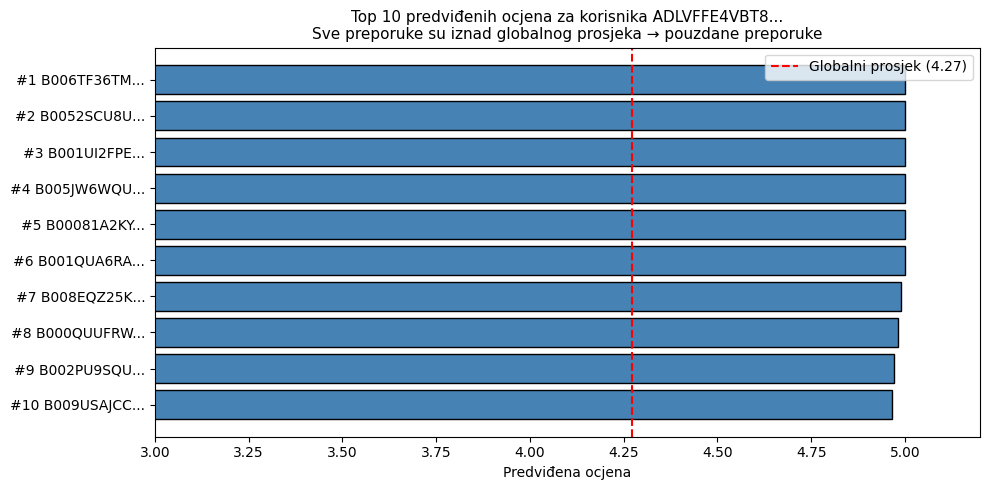

In [8]:
def get_top_n_recommendations(model, user_id, df_filtered, n=10):

    # Proizvodi koje je korisnik već ocijenio → isključujemo ih
    already_rated = set(df_filtered[df_filtered['userId'] == user_id]['productId'])

    # Svi proizvodi u filtriranom skupu podataka
    all_products  = set(df_filtered['productId'].unique())

    # Samo proizvodi koje korisnik još nije ocijenio
    unseen = all_products - already_rated

    # Predviđanje ocjene za svaki neocijenjeni proizvod
    predictions = [
        (pid, model.predict(user_id, pid).est)
        for pid in unseen
    ]

    # Sortiranje po predviđenoj ocjeni (opadajuće)
    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:n]


# Biramo prvog korisnika za demonstraciju 
sample_user = df_filtered['userId'].value_counts().index[0]
n_rated_by_user = df_filtered[df_filtered['userId'] == sample_user].shape[0]

print(f"Korisnik: {sample_user}")
print(f"Već je ocijenio {n_rated_by_user} proizvoda u filtriranom skupu.")
print(f"\nTop 10 preporuka (proizvodi koje još NIJE ocijenio):\n")

recs = get_top_n_recommendations(model, sample_user, df_filtered, n=10)
rec_df = pd.DataFrame(recs, columns=['ASIN proizvoda', 'Predviđena ocjena'])
rec_df.index = range(1, len(rec_df) + 1)
rec_df['Predviđena ocjena'] = rec_df['Predviđena ocjena'].round(3)

print(rec_df.to_string())

# Horizontalni bar graf top 10 predikcija 
plt.figure(figsize=(10, 5))
plt.barh(
    [f"#{i+1} {pid[:10]}..." for i, (pid, _) in enumerate(recs)],
    [score for _, score in recs],
    color='steelblue', edgecolor='black'
)
plt.xlim(3, 5.2)
plt.axvline(x=trainset.global_mean, color='red', linestyle='--',
            label=f'Globalni prosjek ({trainset.global_mean:.2f})')
plt.title(f'Top 10 predviđenih ocjena za korisnika {sample_user[:12]}...\n'
          f'Sve preporuke su iznad globalnog prosjeka → pouzdane preporuke', fontsize=11)
plt.xlabel('Predviđena ocjena')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()